# Comprehensive Model Comparison: Ecommerce Deliveries

This notebook provides an in-depth comparative analysis of several machine learning classification algorithms to predict product seasonality. We emphasize unique visualizations for each model to understand their internal mechanisms and decision-making processes.

### Algorithms Implemented:
1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**
4. **k-Nearest Neighbors (kNN)**
5. **Support Vector Machine (SVM)**
6. **Naive Bayes**

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set(style="whitegrid", palette="muted")

In [2]:
# Load dataset
df = pd.read_csv('diversified_ecommerce_dataset.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 1000000 rows and 16 columns.


## 2. Data Preprocessing and Feature Engineering

In [3]:
# Drop non-informative columns
df = df.drop('Product ID', axis=1)

# Encode categorical variables
le = LabelEncoder()
cat_cols = ['Product Name', 'Category', 'Supplier ID', 'Customer Age Group', 
            'Customer Location', 'Customer Gender', 'Shipping Method']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Map target variable to numeric
df['Seasonality'] = df['Seasonality'].map({'Yes': 1, 'No': 0})

X = df.drop('Seasonality', axis=1)
y = df['Seasonality']

# Scaling for distance-based models
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Initial split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Optimized sampling for comparison (5000 train / 5000 test)
X_train, _, y_train, _ = train_test_split(X_train_full, y_train_full, train_size=5000, stratify=y_train_full, random_state=42)
X_test, _, y_test, _ = train_test_split(X_test_full, y_test_full, train_size=5000, stratify=y_test_full, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (5000, 14)
Testing set size: (5000, 14)


## 3. Algorithm Implementation & Visualizations

### 3.1 Logistic Regression
Logistic regression is a linear model that estimates the probability of binary outcomes. 

**Visualization**: *ROC Curve and Odds Ratios*.

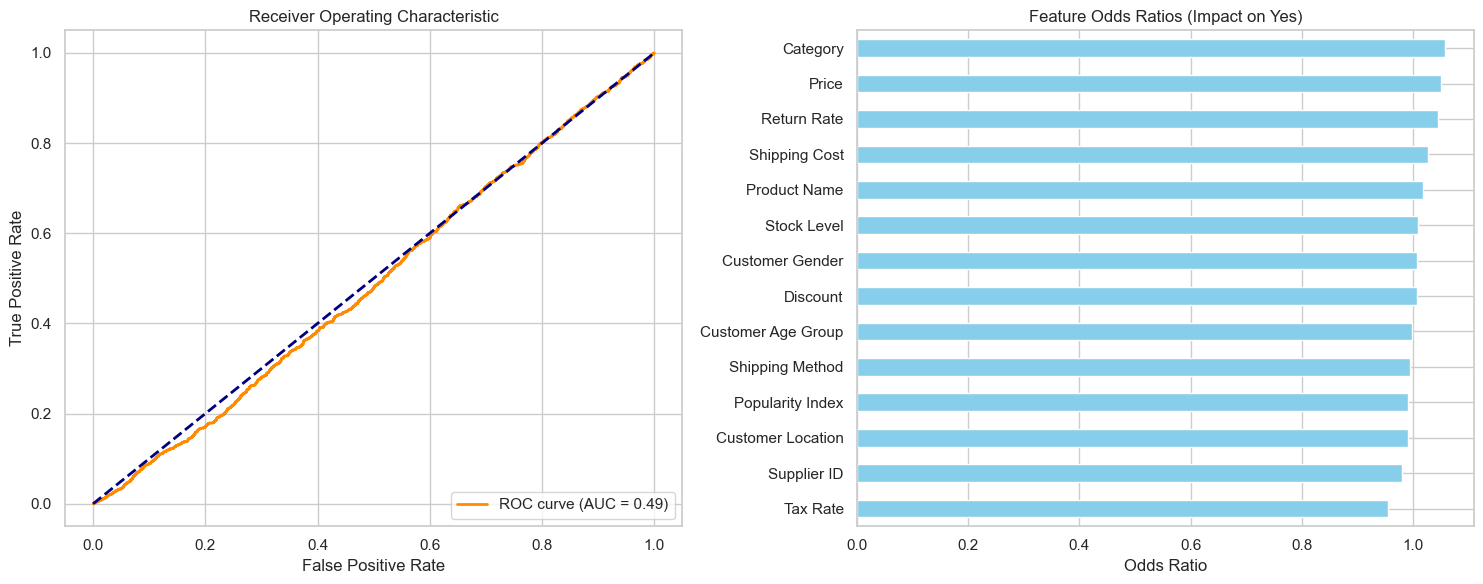

In [4]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_y_score = lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_y_score)

plt.figure(figsize=(15, 6))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(lr_fpr, lr_tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc(lr_fpr, lr_tpr):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# Subplot 2: Odds Ratios
plt.subplot(1, 2, 2)
weights = pd.Series(np.exp(lr_model.coef_[0]), index=X.columns).sort_values()
weights.plot(kind='barh', color='skyblue')
plt.title('Feature Odds Ratios (Impact on Yes)')
plt.xlabel('Odds Ratio')

plt.tight_layout()
plt.show()

### 3.2 Decision Tree
A tree-based model that splits data into branches based on feature values.

**Visualization**: *Truncated Tree Structure*.

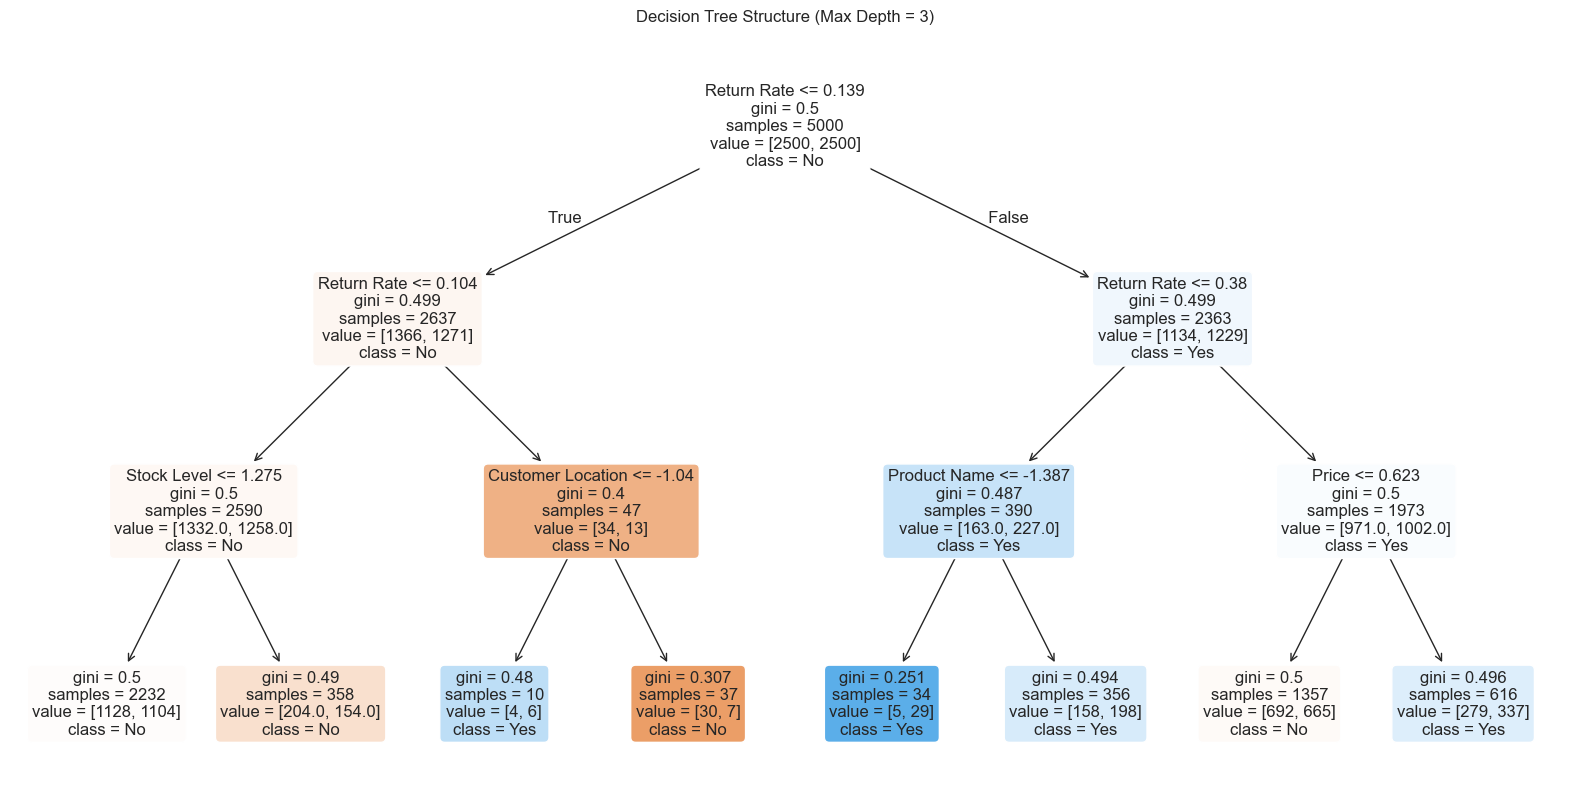

In [5]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=12)
plt.title('Decision Tree Structure (Max Depth = 3)')
plt.show()

### 3.3 Random Forest
An ensemble of multiple decision trees to improve prediction accuracy.

**Visualization**: *Feature Importance*.

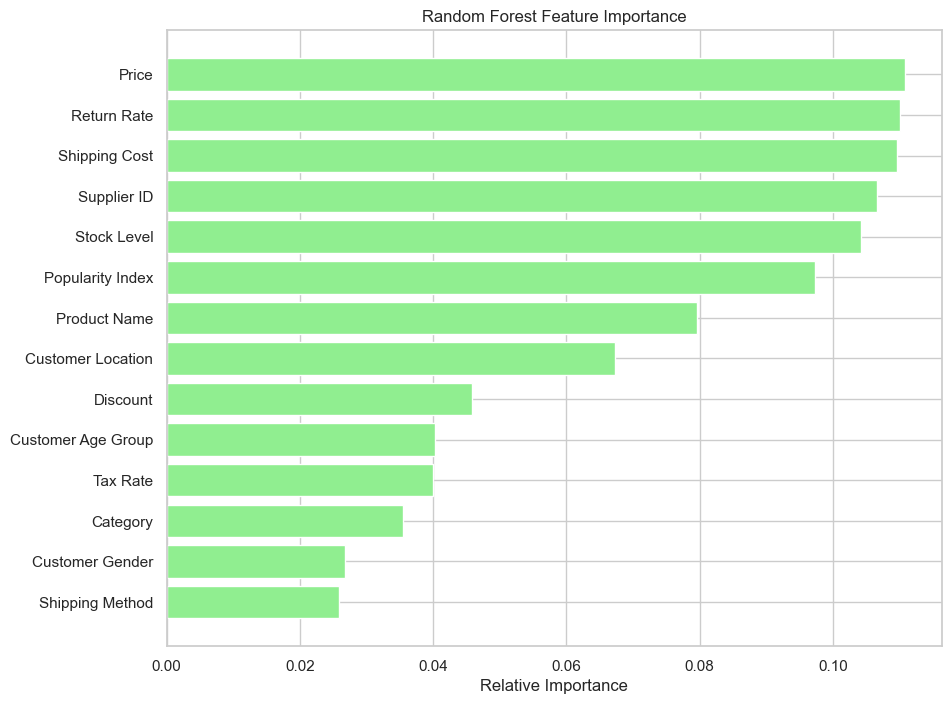

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Random Forest Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='lightgreen', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### 3.4 k-Nearest Neighbors (kNN)
A distance-based model that classifies points based on their nearest neighbors.

**Visualization**: *Accuracy vs Number of Neighbors (K)*.

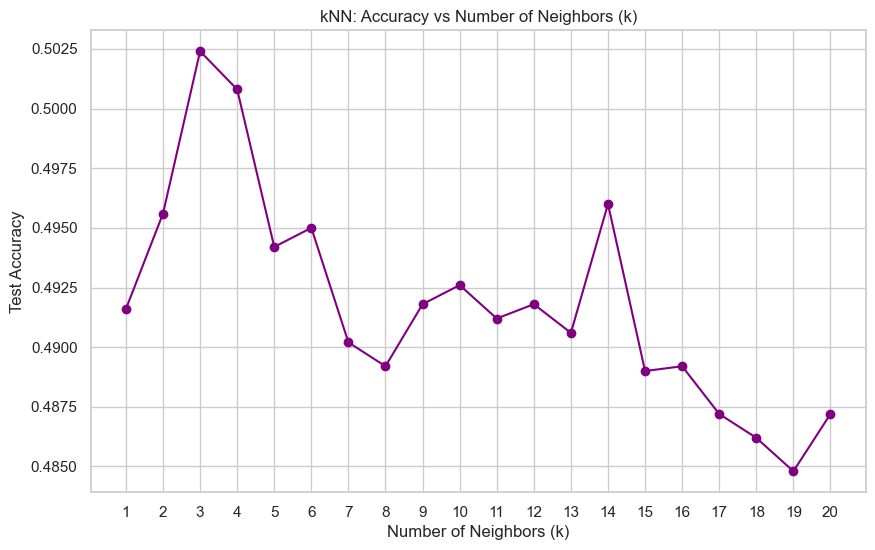

In [7]:
neighbors = range(1, 21)
accuracies = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(knn.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-', color='purple')
plt.title('kNN: Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(neighbors)
plt.grid(True)
plt.show()

### 3.5 Support Vector Machine (SVM)
Finds an optimal hyperplane to separate classes with the maximum margin.

**Visualization**: *Confusion Matrix Heatmap*.

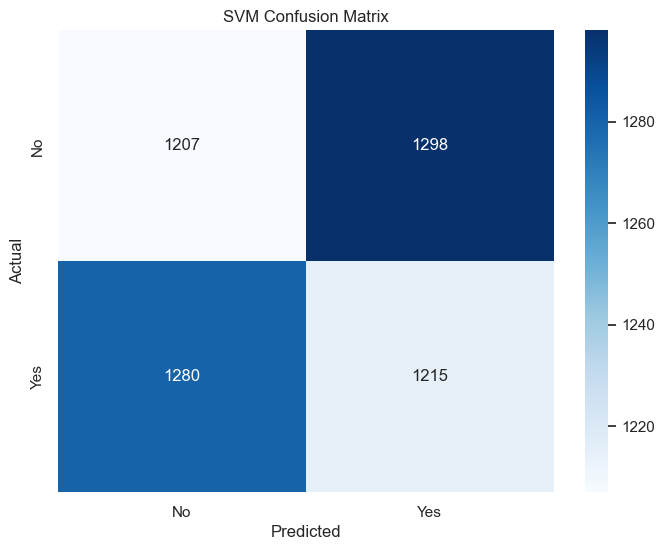

In [8]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_y_pred = svm_model.predict(X_test)

cm = confusion_matrix(y_test, svm_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 3.6 Naive Bayes
A probabilistic model based on Bayes' theorem assuming feature independence.

**Visualization**: *Probability Distribution for Selected Feature*.

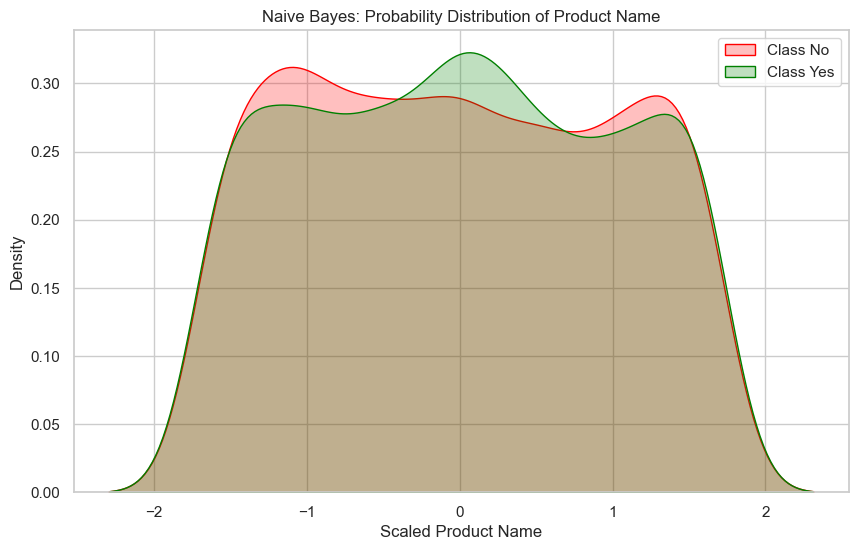

In [9]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Select a feature to show distribution, e.g., index 0 (scaled feature)
feature_idx = 0
feat_name = X.columns[feature_idx]

plt.figure(figsize=(10, 6))
sns.kdeplot(X_train[y_train == 0].iloc[:, feature_idx], label="Class No", color='red', fill=True)
sns.kdeplot(X_train[y_train == 1].iloc[:, feature_idx], label="Class Yes", color='green', fill=True)
plt.title(f'Naive Bayes: Probability Distribution of {feat_name}')
plt.xlabel(f'Scaled {feat_name}')
plt.ylabel('Density')
plt.legend()
plt.show()

## 4. Final Comparison and Evaluation

In [10]:
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': svm_model,
    'Naive Bayes': nb_model
}

all_results = {}

for name, model in models.items():
    if name == 'kNN':
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    all_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

comparison_df = pd.DataFrame(all_results).T
print("Model Comparison Summary:")
display(comparison_df)

Model Comparison Summary:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.4902,0.489024,0.482164,0.485570
Decision Tree,0.4890,0.469574,0.185571,0.266016
Random Forest,0.4906,0.489300,0.476553,0.482843
kNN,0.4942,0.493112,0.487776,0.490429
SVM,0.4844,0.483486,0.486974,0.485224
Naive Bayes,0.4872,0.486061,0.482164,0.484105


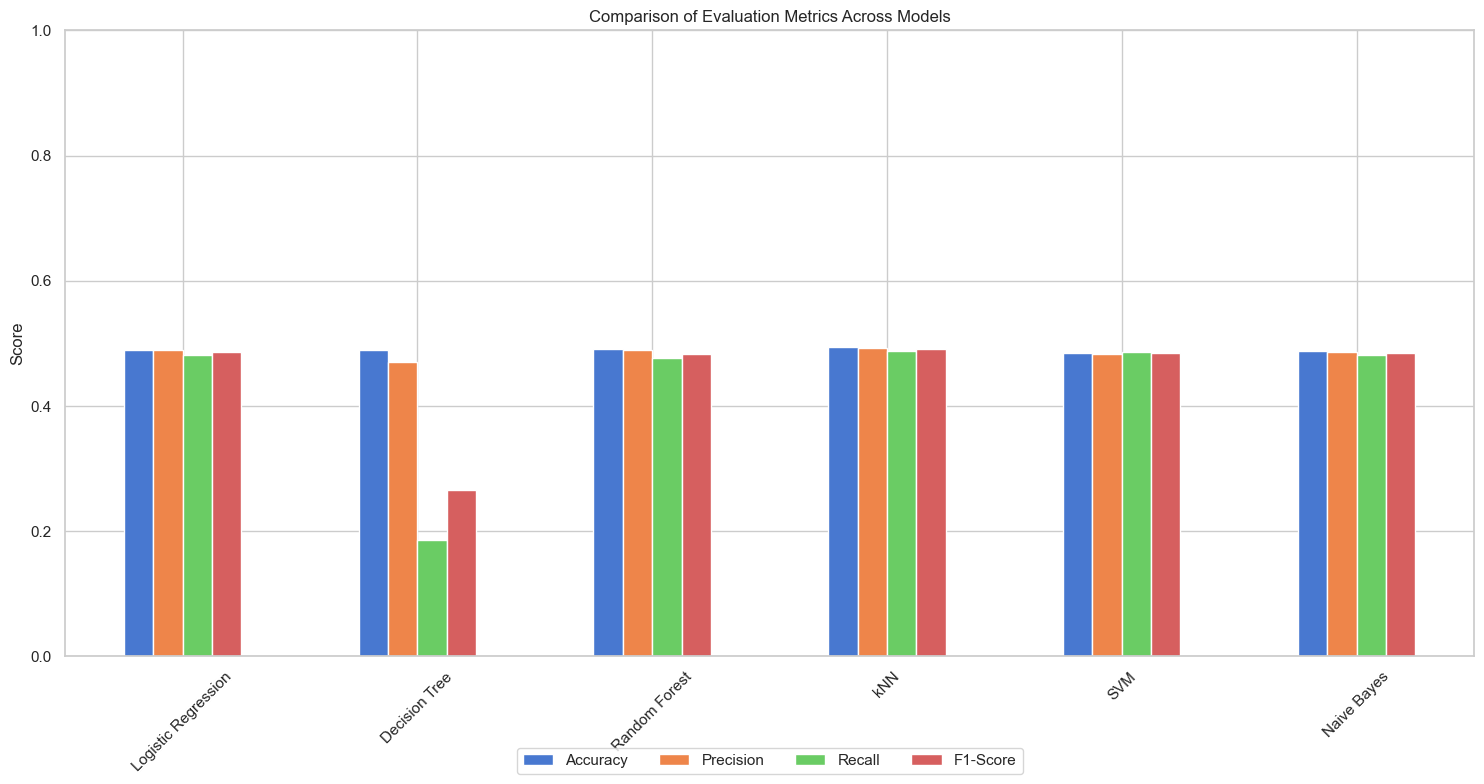

In [11]:
comparison_df.plot(kind='bar', figsize=(15, 8))
plt.title('Comparison of Evaluation Metrics Across Models')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()